<h2>Лабораторна робота №5</h2>
<h3>Моделювання згорткової нейронної мережі</h3>

Завантаження даних...
Початок навчання мережі...
Epoch 1/2
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.9296 - loss: 0.2230 - val_accuracy: 0.9755 - val_loss: 0.0819
Epoch 2/2
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - accuracy: 0.9737 - loss: 0.0846 - val_accuracy: 0.9833 - val_loss: 0.0583
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Обчислення для Варіанту 5 (x=7):
y = sin|7| * cos(3*7/2) = -0.3124
z = 7 * sin(7 + y) = 2.7542

--- Результати тестування ---
Реальна цифра: 7
Розпізнана цифра: 7
y = -0.3124, z = 2.7542


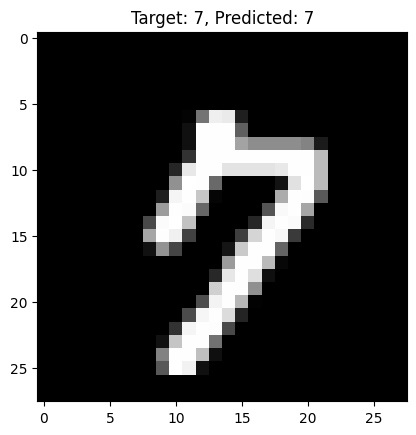

In [1]:
# !!! Немає діскретної відеокарти на моєму ноутбуці

# Імпортується бібліотека NumPy для роботи з масивами, векторами та математичними операціями
import numpy as np 
# Імпортується Matplotlib для побудови графіків і візуалізації зображень
import matplotlib.pyplot as plt 
# Імпортується модуль warnings і вимикаються всі попередження, щоб вони не засмічували консоль.
import warnings
warnings.filterwarnings("ignore")

# Імпортується модуль для роботи з операційною системою
import os
# Приховуються інформаційні та попереджувальні повідомлення TensorFlow (показуються лише критичні помилки)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
# Дозволяється запуск TensorFlow навіть при дублюванні бібліотек OpenMP (часта проблема на Linux)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# Імпортується система логування Python
import logging
# Зменшується рівень логування TensorFlow — показуються лише warning та серйозніші повідомлення
logging.getLogger("tensorflow").setLevel(logging.WARNING)

# Імпортується бібліотека TensorFlow для створення нейронних мереж
import tensorflow as tf
# виконується жорсткіше приглушення логів TensorFlow — тільки критичні помилки
tf.get_logger().setLevel('FATAL') 


# Імпортуються модулі Keras для: layers — шарів нейронної мережі, models — побудови моделей
from tensorflow.keras import layers, models
# Імпортується стандартний датасет MNIST (рукописні цифри 0–9)
# MNIST (Modified National Institute of Standards and Technology) — це класичний набір даних рукописних цифр (0-9)
from tensorflow.keras.datasets import mnist

# Імпортується збирач сміття Python для ручного очищення пам’яті
import gc


# 1. Підготовка даних (Обмеження пам'яті)
# Виводиться повідомлення про початок завантаження даних
print("Завантаження даних...") 
# Завантажується датасет MNIST: train_images, train_labels — навчальні дані; 
#                               test_images, test_labels — тестові дані
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Зміна форми (розмірності) даних без зміни самих значень (решейпінг) для CNN (додаємо канал кольору) та нормалізація
# Нормалізація відразу в float32 для економії
# Додається канал кольору (1 — grayscale), дані перетворюються у float32, 
# Виконується нормалізація до діапазону [0, 1]
#   Згорткові нейронні мережі (CNN) не приймають “плоскі” дані
#   Вони очікують дані у форматі: (кількість_зображень, висота, ширина, канали)
train_images = train_images.reshape((-1, 28, 28, 1)).astype('float32') / 255
# Те саме робиться для тестових зображень
test_images = test_images.reshape((-1, 28, 28, 1)).astype('float32') / 255

# 2. Створюється послідовна CNN-модель
# Оптимізована структура CNN Згорткової нейронної мережі (менше параметрів)
model = models.Sequential([ 
    # Перший згортковий шар: 8 фільтрів, ядро 3×3, ReLU (Rectified Linear Unit) -активація, вхідний розмір 28×28×1
    layers.Conv2D(8, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Шар підвибірки (max pooling), який зменшує розмір карти ознак у 2 рази
    layers.MaxPooling2D((2, 2)),
    
    # Другий згортковий шар: 16 фільтрів, складніше представлення ознак
    layers.Conv2D(16, (3, 3), activation='relu'),
    # Ще раз зменшується просторовий розмір ознак
    layers.MaxPooling2D((2, 2)),
    
    # Перетворення в одновимірний вектор та повнозв'язні шари
    layers.Flatten(),
    # Другий згортковий шар: 16 нейронів, складніше представлення ознак: менше нейронів у повнозв'язному шарі
    layers.Dense(16, activation='relu'), 
    # Вихідний шар: 10 нейронів, softmax → ймовірності для цифр 0–9
    layers.Dense(10, activation='softmax')
])

# 3. Компіляція та навчання
# adam — оптимізатор, sparse_categorical_crossentropy — функція втрат для міток 0–9, accuracy — метрика точності
# Оптимізовано з малим Batch Size
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Виводиться повідомлення про початок навчання мережі
print("Початок навчання мережі...")
# Скорочено кількість епох та зменшено розмір пакету (batch_size)
# Навчання мережі: 2 епохи, batch size = 8 (економія пам’яті), 10% даних — для валідації
#    Епоха — це один повний прохід нейромережі по всьому тренувальному набору даних
#    Batch_size = скільки зображень (або прикладів) мережа бере за раз
model.fit(train_images, train_labels, 
          epochs=2, 
          batch_size=8, 
          validation_split=0.1)

# Очищення пам'яті від тренувальних даних після навчання
del train_images
del train_labels
gc.collect() # Збирач сміття для очищення пам'яті

# 4. Демонстрація працездатності та виконання обчислень Варіанту 5
# Оголошується функція calculate_variant_5 для обчислення формул Варіанту 5
def calculate_variant_5(x):
    # Формули з Варіанту 5:
    # y = sin|x| * cos(3x/2)
    # z = x * sin(x + y)
    y_res = np.sin(np.abs(x)) * np.cos(3 * x / 2)
    z_res = x * np.sin(x + y_res)
    return y_res, z_res # Повертаються значення y та z

# Тестування на випадковому зображенні
idx = np.random.randint(0, len(test_images)) # Випадково вибирається індекс тестового зображення.
sample_img = test_images[idx:idx+1] # Береться одне зображення
prediction = model.predict(sample_img) # Модель прогнозує клас цифри
predicted_digit = int(np.argmax(prediction)) # Обирається цифра з максимальною ймовірністю

# Обчислення за формулами Варіанту 5 для x = predicted_digit
y_v5, z_v5 = calculate_variant_5(predicted_digit) # Підставляється розпізнана цифра у формули Варіанту 5
print(f"Обчислення для Варіанту 5 (x={predicted_digit}):") # Виводиться повідомлення про початок обчислення
# Виводиться обчислення y
print(f"y = sin|{predicted_digit}| * cos(3*{predicted_digit}/2) = {y_v5:.4f}") 
# Виводиться обчислення z
print(f"z = {predicted_digit} * sin({predicted_digit} + y) = {z_v5:.4f}")

print(f"\n--- Результати тестування ---") # Виводиться повідомлення Результати тестування 
print(f"Реальна цифра: {test_labels[idx]}") # Виводиться реальна цифра
print(f"Розпізнана цифра: {predicted_digit}") # Виводиться розпізнана цифра
print(f"y = {y_v5:.4f}, z = {z_v5:.4f}") # Виводяться результати y та z 

# Візуалізація
# Візуалізація тестового зображення
plt.imshow(test_images[idx].reshape(28, 28), cmap='gray') 
# Надається назву зображенню
plt.title(f"Target: {test_labels[idx]}, Predicted: {predicted_digit}")
plt.show() # Зображується графічну сітку

# ==============================================================================
# КОНТРОЛЬНІ ЗАПИТАННЯ:
# ==============================================================================
# 1. CNN — це архітектура, що використовує операцію згортки для виділення ознак. 
#    Використовується для аналізу зображень та відео.
# 2. Головна відмінність — CNN використовує спільні ваги (фільтри) та враховує просторову структуру даних, 
#    тоді як повнозв'язні мережі ігнорують топологію.
# 3. Згортка — це математична операція множення ядра (матриці ваг) на локальні ділянки вхідного зображення.
# 4. Фільтри автоматично знаходять патерни (краї, лінії, кути).
# 5. Feature maps — це результат застосування фільтрів до вхідних даних; 
#    вони показують, де саме на зображенні знайдено конкретну ознаку.
# 6. Pooling зменшує розмірність карти ознак, зберігаючи найважливішу інформацію та зменшуючи кількість параметрів.
# 7. Max pooling бере максимальне значення з вікна, Average pooling — середнє.
# 8. Padding — додавання нулів по краях для збереження розміру; Stride — крок, з яким рухається фільтр.
# 9. Великий Stride зменшує вихід, Padding — збільшує або зберігає його.
# 10. Convolutional (згорткові), Pooling (підвибірки), Fully Connected (повнозв'язні).
# 11. Overfitting — коли мережа просто "зазубрює" тренувальні дані. Зменшується через Dropout або регуляризацію.
# 12. Dropout (відключення нейронів), Data Augmentation (випадкові повороти/зсуви зображень).
# 13. Через інваріантність до зсуву та ефективне виділення ієрархічних ознак.
# 14. Обробка природної мови (NLP), аналіз аудіо, медична діагностика.
# 15. Переваги: висока точність, менше параметрів ніж у Dense. 
#     Недоліки: вимагає багато обчислювальних ресурсів та великої кількості даних.
# ==============================================================================

<h2>Виконала студентка групи ЗПІ-зп41  <br>Грищенко Юлія</h2>
